In [17]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [18]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from models.small_cnn import SmallCNN
from attacks.fgsm import fgsm

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

test_dataset = torchvision.datasets.CIFAR10(
    root="../models/data", train=False, download=False, transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False
)

In [21]:
def evaluate(model, loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, pred = outputs.max(1)

            total += y.size(0)
            correct += pred.eq(y).sum().item()

    return 100 * correct / total

In [25]:
model = SmallCNN().to(device)
model.load_state_dict(torch.load("../models/checkpoints/cnn_cifar10.pt", map_location=device))
model.eval()

SmallCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

In [26]:
epsilons = [0, 0.01, 0.03, 0.05, 0.1, 0.2]

for eps in epsilons:
    correct = 0
    total = 0

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        if eps == 0:
            x_adv = x
        else:
            x_adv = fgsm(model, x, y, eps)

        outputs = model(x_adv)
        _, pred = outputs.max(1)

        total += y.size(0)
        correct += pred.eq(y).sum().item()

    acc = 100 * correct / total
    print(f"Epsilon: {eps:.2f} | Accuracy: {acc:.2f}%")

Epsilon: 0.00 | Accuracy: 73.15%
Epsilon: 0.01 | Accuracy: 30.69%
Epsilon: 0.03 | Accuracy: 4.48%
Epsilon: 0.05 | Accuracy: 1.16%
Epsilon: 0.10 | Accuracy: 0.55%
Epsilon: 0.20 | Accuracy: 1.48%


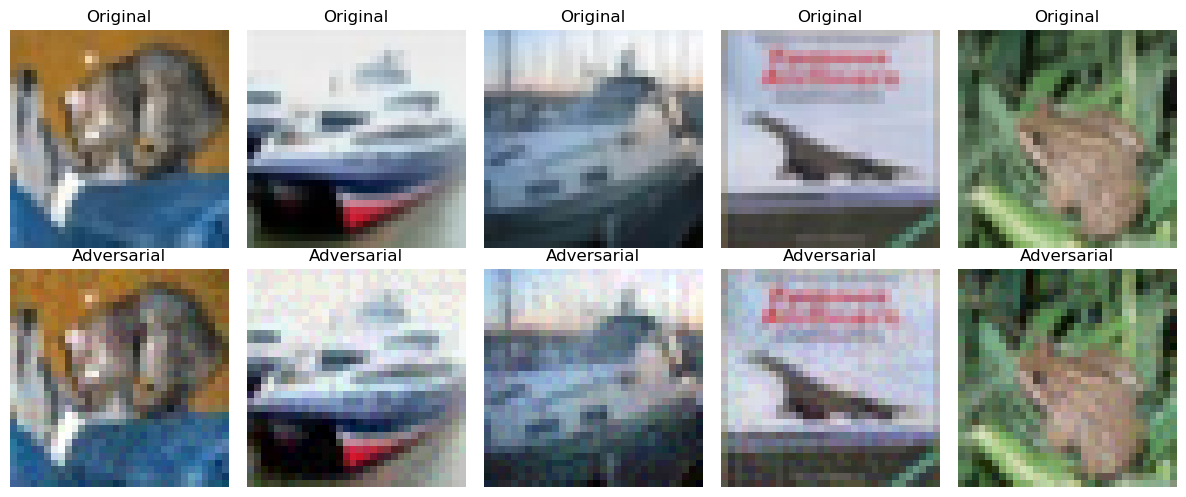

In [27]:
classes = test_dataset.classes

data_iter = iter(test_loader)
x, y = next(data_iter)

x, y = x.to(device), y.to(device)

epsilon = 0.03
x_adv = fgsm(model, x, y, epsilon)


x = x.cpu()
x_adv = x_adv.cpu()

fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i in range(5):
    # original
    axes[0, i].imshow(x[i].permute(1,2,0))
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    # adversarial
    axes[1, i].imshow(x_adv[i].permute(1,2,0))
    axes[1, i].set_title("Adversarial")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()